<a href="https://colab.research.google.com/github/Buddhiimz/DeepLearning_Project/blob/feature%2Fjithma/IT22095176_DL_Assigment_EfficientNetB0_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# imports and settings
import os, glob
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix
tf.random.set_seed(123)
np.random.seed(123)

In [5]:
# Mount Google Drive to access datasets
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Extract train zip folders
import zipfile
with zipfile.ZipFile('/content/drive/MyDrive/Colab Notebooks/Assignment/train.zip', 'r') as zip_ref:
    zip_ref.extractall('train')

In [ ]:
# Extract test zip folders
import zipfile
with zipfile.ZipFile('/content/drive/MyDrive/Colab Notebooks/Assignment/test.zip', 'r') as zip_ref:
    zip_ref.extractall('test')

In [ ]:
# Cell 2: check folder structure and classes
TRAIN_DIR = '/content/train/train'
TEST_DIR  = '/content/test/test'

def list_class_folders(path):
    classes = [d for d in sorted(os.listdir(path)) if os.path.isdir(os.path.join(path, d))]
    return classes

train_classes = list_class_folders(TRAIN_DIR)
test_classes  = list_class_folders(TEST_DIR)

print("Detected train classes (count={}):".format(len(train_classes)), train_classes)
print("Detected test classes (count={}):".format(len(test_classes)), test_classes)

# show per-class counts (train)
def class_counts(path, classes):
    counts = {}
    for c in classes:
        p = os.path.join(path, c)
        files = [f for f in glob.glob(os.path.join(p, '*')) if os.path.isfile(f)]
        counts[c] = len(files)
    return counts

if train_classes:
    print("Train image counts by class:", class_counts(TRAIN_DIR, train_classes))
else:
    print("No class subfolders detected in", TRAIN_DIR, "- check your extraction.")


Detected train classes (count=52): ['n0000', 'n0001', 'n0002', 'n0003', 'n0004', 'n0005', 'n0006', 'n0007', 'n0008', 'n0009', 'n0010', 'n0011', 'n0012', 'n0013', 'n0014', 'n0015', 'n0016', 'n0017', 'n0018', 'n0019', 'n0020', 'n0021', 'n0022', 'n0023', 'n0024', 'n0025', 'n0026', 'n0027', 'n0028', 'n0029', 'n0030', 'n0031', 'n0032', 'n0033', 'n0034', 'n0035', 'n0036', 'n0037', 'n0038', 'n0039', 'n0040', 'n0041', 'n0042', 'n0043', 'n0044', 'n0045', 'n0046', 'n0047', 'n0048', 'n0049', 'n0050', 'n0051']
Detected test classes (count=52): ['n0000', 'n0001', 'n0002', 'n0003', 'n0004', 'n0005', 'n0006', 'n0007', 'n0008', 'n0009', 'n0010', 'n0011', 'n0012', 'n0013', 'n0014', 'n0015', 'n0016', 'n0017', 'n0018', 'n0019', 'n0020', 'n0021', 'n0022', 'n0023', 'n0024', 'n0025', 'n0026', 'n0027', 'n0028', 'n0029', 'n0030', 'n0031', 'n0032', 'n0033', 'n0034', 'n0035', 'n0036', 'n0037', 'n0038', 'n0039', 'n0040', 'n0041', 'n0042', 'n0043', 'n0044', 'n0045', 'n0046', 'n0047', 'n0048', 'n0049', 'n0050', 'n

In [ ]:
# 🔹 Orchid class name mapping
class_names = {
    "n0000": "anoectochilus burmanicus rolfe",
    "n0001": "bulbophyllum auricomum lindl.",
    "n0002": "bulbophyllum dayanum rchb",
    "n0003": "bulbophyllum lasiochilum par. & rchb",
    "n0004": "bulbophyllum limbatum",
    "n0005": "bulbophyllum longissimum (ridl.) ridl",
    "n0006": "bulbophyllum medusae (lindl.) rchb",
    "n0007": "bulbophyllum patens king ex hk.f.",
    "n0008": "bulbophyllum rufuslabram",
    "n0009": "bulbophyllum siamensis rchb",
    "n0010": "calenthe rubens",
    "n0011": "chiloschista parishii seidenf.",
    "n0012": "chiloschista viridiflora seidenf.",
    "n0013": "cymbidium aloifolium (l.) sw.",
    "n0014": "dendrobium chrysotoxum lindl",
    "n0015": "dendrobium farmeri paxt.",
    "n0016": "dendrobium fimbriatum hook",
    "n0017": "dendrobium lindleyi steud",
    "n0018": "dendrobium pulchellum roxb",
    "n0019": "dendrobium pulchellum",
    "n0020": "dendrobium secundum bl-lindl",
    "n0021": "dendrobium senile par. & rchb.f.",
    "n0022": "dendrobium signatum rchb. f",
    "n0023": "dendrobium thyrsiflorum rchb. f.",
    "n0024": "dendrobium tortile lindl",
    "n0025": "dendrobium tortile",
    "n0026": "hygrochillus parishii var. marrioftiana (rchb.f.)",
    "n0027": "paphiopedilum bellatulum",
    "n0028": "paphiopedilum callosum",
    "n0029": "paphiopedilum charlesworthii",
    "n0030": "paphiopedilum concolor",
    "n0031": "paphiopedilum exul",
    "n0032": "paphiopedilum godefroyae",
    "n0033": "paphiopedilum gratrixianum",
    "n0034": "paphiopedilum henryanum",
    "n0035": "paphiopedilum intanon-villosum",
    "n0036": "paphiopedilum niveum (rchb.f.) stein",
    "n0037": "paphiopedilum parishii",
    "n0038": "paphiopedilum spicerianum",
    "n0039": "paphiopedilum sukhakulii",
    "n0040": "pelatantheria bicuspidata (rolfe ex downie) tang & wang",
    "n0041": "pelatantheria insectiflora (rchb.f.) ridl.",
    "n0042": "phaius tankervilleae (banks ex i' heritier) blume",
    "n0043": "phalaenopsis cornucervi (breda) bl. & rchb.f.",
    "n0044": "rhynchostylis gigantea (lindl.) ridl.",
    "n0045": "trichoglottis orchideae (koern) garay.",
    "n0046": "bulbophyllum auratum lindl.",
    "n0047": "bulbophyllum morphologorum f.kranzl.",
    "n0048": "dendrobium cumulatum lindl.",
    "n0049": "maxiralia tenui folia",
    "n0050": "paphiopedilum vejvarutianum o. gruss & roellke",
    "n0051": "oncidium goldiana"
}


In [ ]:
# Cell 3: dataset creation
IMG_SIZE = 224   # EfficientNetB0 typically uses 224; you can try 240 later
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset='training',
    seed=123
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset='validation',
    seed=123
)

# Test dataset: ensure shuffle=False so predictions line up
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print("Classes:", class_names)
print("Num classes:", NUM_CLASSES)

# Performance
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)


Found 2820 files belonging to 52 classes.
Using 2256 files for training.
Found 2820 files belonging to 52 classes.
Using 564 files for validation.
Found 739 files belonging to 52 classes.
Classes: ['n0000', 'n0001', 'n0002', 'n0003', 'n0004', 'n0005', 'n0006', 'n0007', 'n0008', 'n0009', 'n0010', 'n0011', 'n0012', 'n0013', 'n0014', 'n0015', 'n0016', 'n0017', 'n0018', 'n0019', 'n0020', 'n0021', 'n0022', 'n0023', 'n0024', 'n0025', 'n0026', 'n0027', 'n0028', 'n0029', 'n0030', 'n0031', 'n0032', 'n0033', 'n0034', 'n0035', 'n0036', 'n0037', 'n0038', 'n0039', 'n0040', 'n0041', 'n0042', 'n0043', 'n0044', 'n0045', 'n0046', 'n0047', 'n0048', 'n0049', 'n0050', 'n0051']
Num classes: 52


In [ ]:
# Cell 4: augmentation and class weights
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.08),
    # you can add RandomContrast, RandomTranslation etc.
], name='data_augmentation')

# compute simple class weights to address imbalance
counts = [len(glob.glob(os.path.join(TRAIN_DIR, c, '*'))) for c in class_names]
total = sum(counts)
class_weights = {i: total / (NUM_CLASSES * counts[i]) for i in range(NUM_CLASSES)}
print("Per-class counts:", dict(zip(class_names, counts)))
print("Class weights:", class_weights)


Per-class counts: {'n0000': 48, 'n0001': 48, 'n0002': 22, 'n0003': 49, 'n0004': 18, 'n0005': 29, 'n0006': 23, 'n0007': 16, 'n0008': 25, 'n0009': 43, 'n0010': 19, 'n0011': 88, 'n0012': 49, 'n0013': 70, 'n0014': 50, 'n0015': 43, 'n0016': 66, 'n0017': 144, 'n0018': 104, 'n0019': 51, 'n0020': 92, 'n0021': 28, 'n0022': 26, 'n0023': 22, 'n0024': 165, 'n0025': 19, 'n0026': 31, 'n0027': 90, 'n0028': 58, 'n0029': 76, 'n0030': 67, 'n0031': 59, 'n0032': 105, 'n0033': 110, 'n0034': 31, 'n0035': 61, 'n0036': 27, 'n0037': 28, 'n0038': 71, 'n0039': 69, 'n0040': 49, 'n0041': 75, 'n0042': 26, 'n0043': 50, 'n0044': 90, 'n0045': 36, 'n0046': 32, 'n0047': 57, 'n0048': 21, 'n0049': 28, 'n0050': 55, 'n0051': 61}
Class weights: {0: 1.1298076923076923, 1: 1.1298076923076923, 2: 2.465034965034965, 3: 1.1067503924646782, 4: 3.0128205128205128, 5: 1.870026525198939, 6: 2.3578595317725752, 7: 3.389423076923077, 8: 2.169230769230769, 9: 1.2611806797853309, 10: 2.854251012145749, 11: 0.6162587412587412, 12: 1.10675

In [ ]:
# Cell 5: create model (stage 1: feature extractor frozen)
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)                     # augmentation on-the-fly
x = layers.Lambda(preprocess_input, name='preproc')(x)  # EfficientNet preprocessing
base_model = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D(name='gap')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preproc (Lambda)                │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 52)             │        66,612 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,116,183 (15.70 MB)

 Trainable params: 66,612 (260.20 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
# Cell 6: callbacks and train head
CHECKPOINT_PATH = '/content/best_effnetb0.weights.h5'
cb_checkpoint = callbacks.ModelCheckpoint(CHECKPOINT_PATH, monitor='val_accuracy',
                                          save_best_only=True, save_weights_only=True, verbose=1)
cb_reduce = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
cb_early = callbacks.EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1)

EPOCHS_HEAD = 10
history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    callbacks=[cb_checkpoint, cb_reduce, cb_early],
    class_weight=class_weights
)


Epoch 1/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.0258 - loss: 4.1082
Epoch 1: val_accuracy improved from -inf to 0.09043, saving model to /content/best_effnetb0.weights.h5
71/71 ━━━━━━━━━━━━━━━━━━━━ 347s 4s/step - accuracy: 0.0259 - loss: 4.1064 - val_accuracy: 0.0904 - val_loss: 3.6961 - learning_rate: 1.0000e-04
Epoch 2/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1020 - loss: 3.6705
Epoch 2: val_accuracy improved from 0.09043 to 0.25000, saving model to /content/best_effnetb0.weights.h5
71/71 ━━━━━━━━━━━━━━━━━━━━ 261s 4s/step - accuracy: 0.1022 - loss: 3.6699 - val_accuracy: 0.2500 - val_loss: 3.3701 - learning_rate: 1.0000e-04
Epoch 3/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2270 - loss: 3.3262
Epoch 3: val_accuracy improved from 0.25000 to 0.41667, saving model to /content/best_effnetb0.weights.h5
71/71 ━━━━━━━━━━━━━━━━━━━━ 270s 4s/step - accuracy: 0.2274 - loss: 3.3262 - val_accuracy: 0.4167 - val_loss: 3.0811 - learning_rate: 1.0000e-04
Epoc

In [ ]:
# Cell 7: fine-tune
# Unfreeze the top layers of the base model
base_model.trainable = True

# Option: freeze a number of initial layers, fine-tune the rest
fine_tune_at = int(len(base_model.layers) * 0.75)  # unfreeze top 25%
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# lower LR for fine-tuning
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

EPOCHS_FINE = 20
initial_epoch = len(history_head.history['loss'])
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=initial_epoch + EPOCHS_FINE,
    initial_epoch=initial_epoch,
    callbacks=[cb_checkpoint, cb_reduce, cb_early],
    class_weight=class_weights
)


Epoch 11/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5298 - loss: 2.6636
Epoch 11: val_accuracy did not improve from 0.75000
71/71 ━━━━━━━━━━━━━━━━━━━━ 365s 5s/step - accuracy: 0.5295 - loss: 2.6631 - val_accuracy: 0.7216 - val_loss: 1.7238 - learning_rate: 1.0000e-05
Epoch 12/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5503 - loss: 2.5083
Epoch 12: val_accuracy did not improve from 0.75000
71/71 ━━━━━━━━━━━━━━━━━━━━ 325s 5s/step - accuracy: 0.5503 - loss: 2.5076 - val_accuracy: 0.6933 - val_loss: 1.8007 - learning_rate: 1.0000e-05
Epoch 13/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5822 - loss: 2.4122
Epoch 13: val_accuracy did not improve from 0.75000
71/71 ━━━━━━━━━━━━━━━━━━━━ 343s 5s/step - accuracy: 0.5825 - loss: 2.4109 - val_accuracy: 0.6826 - val_loss: 1.8086 - learning_rate: 1.0000e-05
Epoch 14/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6484 - loss: 2.1941
Epoch 14: val_accuracy did not improve from 0.75000

Epoch 14: ReduceLROnPla

In [ ]:
# Cell 8: evaluate
model.load_weights(CHECKPOINT_PATH)  # best weights saved by checkpoint
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test loss: {test_loss:.4f}  Test accuracy: {test_acc:.4f}")


24/24 ━━━━━━━━━━━━━━━━━━━━ 62s 3s/step - accuracy: 0.7116 - loss: 1.5613
Test loss: 1.4825  Test accuracy: 0.7294


24/24 ━━━━━━━━━━━━━━━━━━━━ 70s 3s/step
              precision    recall  f1-score   support

       n0000     0.8667    1.0000    0.9286        13
       n0001     0.6111    0.8462    0.7097        13
       n0002     0.7500    1.0000    0.8571         6
       n0003     0.7692    0.7692    0.7692        13
       n0004     0.6000    0.6000    0.6000         5
       n0005     0.8000    1.0000    0.8889         8
       n0006     1.0000    1.0000    1.0000         6
       n0007     0.2000    0.4000    0.2667         5
       n0008     0.0000    0.0000    0.0000         8
       n0009     1.0000    0.9231    0.9600        13
       n0010     1.0000    0.4000    0.5714         5
       n0011     0.7500    0.7826    0.7660        23
       n0012     0.0000    0.0000    0.0000        13
       n0013     0.6842    0.7222    0.7027        18
       n0014     0.3750    0.2308    0.2857        13
       n0015     0.5000    0.3636    0.4211        11
       n0016     0.7500    0.7059    0.727

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


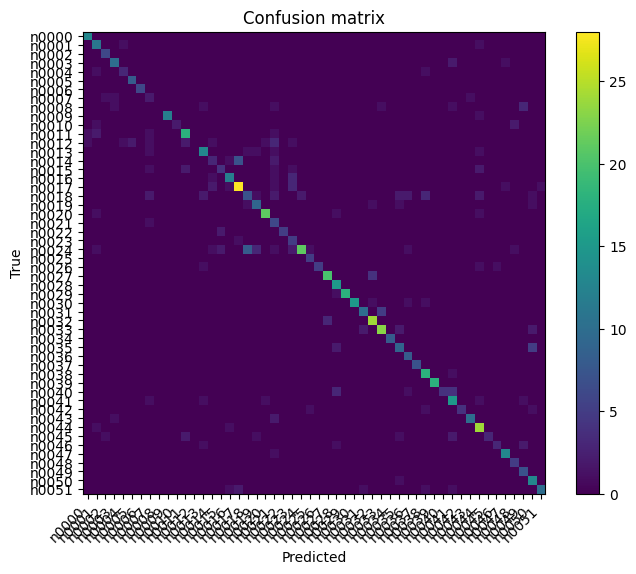

In [ ]:
# Cell9: preds, classification report
# Get y_true
y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0)

# Predictions (probabilities)
y_proba = model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_proba, axis=1)

# Pretty metrics
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix:\n", cm)

# Plot confusion matrix heatmap (simple)
plt.figure(figsize=(8,6))
plt.imshow(cm, interpolation='nearest')
plt.title('Confusion matrix')
plt.colorbar()
plt.xticks(range(NUM_CLASSES), class_names, rotation=45, ha='right')
plt.yticks(range(NUM_CLASSES), class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


In [ ]:
import tensorflow.keras.callbacks as keras_callbacks

callbacks = [cb_checkpoint, cb_reduce, cb_early]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)


Epoch 1/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8074 - loss: 1.3497
Epoch 1: val_accuracy improved from 0.82092 to 0.82270, saving model to /content/best_effnetb0.weights.h5
71/71 ━━━━━━━━━━━━━━━━━━━━ 343s 5s/step - accuracy: 0.8076 - loss: 1.3494 - val_accuracy: 0.8227 - val_loss: 1.1578 - learning_rate: 5.0000e-06
Epoch 2/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8444 - loss: 1.2743
Epoch 2: val_accuracy did not improve from 0.82270
71/71 ━━━━━━━━━━━━━━━━━━━━ 418s 5s/step - accuracy: 0.8443 - loss: 1.2742 - val_accuracy: 0.8227 - val_loss: 1.1127 - learning_rate: 5.0000e-06
Epoch 3/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8360 - loss: 1.2390
Epoch 3: val_accuracy improved from 0.82270 to 0.82624, saving model to /content/best_effnetb0.weights.h5
71/71 ━━━━━━━━━━━━━━━━━━━━ 344s 5s/step - accuracy: 0.8360 - loss: 1.2387 - val_accuracy: 0.8262 - val_loss: 1.0690 - learning_rate: 5.0000e-06
Epoch 4/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accur